# Propuesta 5
## Autor: Yasin Hanin Boukaddidi

In [ ]:
import pandas as pd

df = pd.read_csv("tcga_simple_train.csv")

df.head()

,patient_id,text,t
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3


In [ ]:
labels = list(sorted(set(df['t'].to_list())))
labels

['T1', 'T2', 'T3', 'T4']

In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)

dataset = dataset.rename_column("t", "label")

label2id = {label: i for i, label in enumerate(labels)}
dataset = dataset.map(lambda x: {"label": label2id[x["label"]]})

print("Dataset preparado a partir del DataFrame:")
print(dataset)

Map:   0%|          | 0/5158 [00:00<?, ? examples/s]

Dataset preparado a partir del DataFrame:
Dataset({
    features: ['patient_id', 'text', 'label'],
    num_rows: 5158
})


In [ ]:
NUM_LABELS = len(labels)

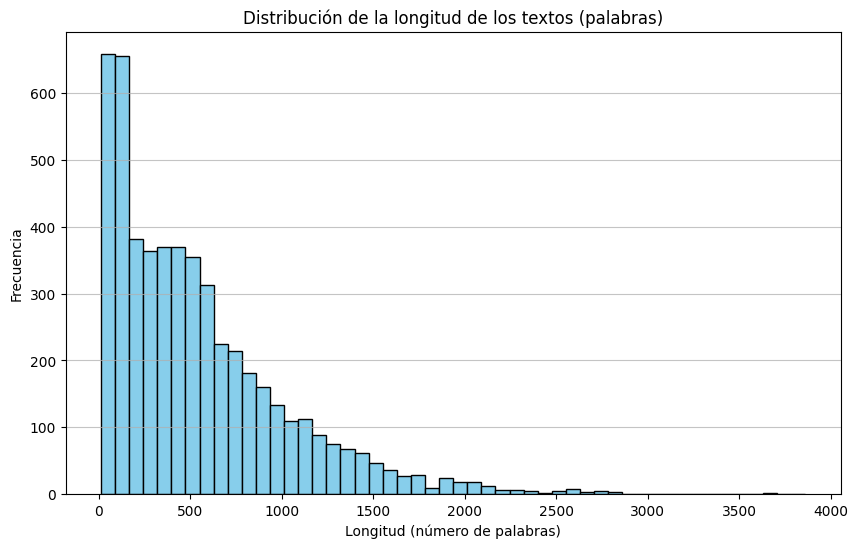

Longitud mínima: 11
Longitud media: 546.44
Longitud máxima: 3862
Percentil 90: 1205.0 (El 90% de los textos tienen esta longitud o menos)
Percentil 95: 1487.2999999999993 (El 95% de los textos tienen esta longitud o menos)

Sugerencia: Un max_length de 512 sería adecuado para cubrir la mayoría de la información sin desperdiciar recursos.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculamos la longitud de los textos (por número de palabras)
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))

# Visualización de la distribución
plt.figure(figsize=(10, 6))
plt.hist(df['text_len'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la longitud de los textos (palabras)')
plt.xlabel('Longitud (número de palabras)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Cálculo de percentiles para sugerir max_len
p90 = np.percentile(df['text_len'], 90)
p95 = np.percentile(df['text_len'], 95)
max_val = df['text_len'].max()

print(f"Longitud mínima: {df['text_len'].min()}")
print(f"Longitud media: {df['text_len'].mean():.2f}")
print(f"Longitud máxima: {max_val}")
print(f"Percentil 90: {p90} (El 90% de los textos tienen esta longitud o menos)")
print(f"Percentil 95: {p95} (El 95% de los textos tienen esta longitud o menos)")

# Sugerencia
suggested_max = min(512, int(p95))
print(f"\nSugerencia: Un max_length de {suggested_max} sería adecuado para cubrir la mayoría de la información sin desperdiciar recursos.")

In [ ]:
from transformers import AutoTokenizer

model_id = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# El modelo BERT tiene un límite estricto de 512 tokens.
# Aunque el dataset tenga textos más largos, debemos truncarlos.
MAX_LENGTH = 512
print(f"Tamaño máximo ajustado al límite de BERT: {MAX_LENGTH}")

Tamaño máximo ajustado al límite de BERT: 512


In [ ]:
# Activamos 'truncation=True' para que los textos de más de 512 tokens se recorten automáticamente.
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

In [ ]:
# se tokeniza todo el dataset por lotes
# sobre el diccionario con los tres split se llama a map para que aplique la función tokenize a cada split y al hacer batched a True se le está diciendo
# que lo haga por lotes
encoded_data = dataset.map(tokenize, batched=True)
encoded_data

Map:   0%|          | 0/5158 [00:00<?, ? examples/s]

Dataset({
    features: ['patient_id', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5158
})

In [ ]:
# Primero, dividimos el dataset único en entrenamiento y una parte temporal (test + val)
train_test_split = encoded_data.train_test_split(test_size=0.2, seed=42)
# Luego dividimos esa parte temporal a la mitad para obtener validación y test
test_val_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)

train_dataset = train_test_split['train']
validation_dataset = test_val_split['train']
test_dataset = test_val_split['test']

In [ ]:
# se puede comprobar que todos los textos tienen el mismo tamaño
import random
for i in range(10):
    index = random.randint(0, train_dataset.num_rows)
    print('text:', index, ' len:', len(train_dataset[index]['input_ids']))


text: 3260  len: 512
text: 2491  len: 512
text: 412  len: 512
text: 1796  len: 512
text: 248  len: 512
text: 138  len: 512
text: 1570  len: 512
text: 2456  len: 512
text: 1773  len: 512
text: 3536  len: 512


In [ ]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained("emilyalsentzer/Bio_ClinicalBERT", num_labels=NUM_LABELS)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
from transformers import TrainingArguments
args = TrainingArguments(output_dir="./outputs")
args.eval_strategy = "epoch"
args.logging_strategy = "epoch"
args.per_device_train_batch_size = 32
args.per_device_eval_batch_size = 32
args.num_train_epochs=5
display(args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=epoch,
eval_use_gather_object=False,
fp16=False,
f

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    y_true = pred.label_ids # labels reales
    y_pred = pred.predictions.argmax(-1) # predicciones

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true,y_pred, average='macro')

    return {
        'accuracy: ': accuracy,
        'f1: ': f1,
        'precision: ': precision,
        'recall: ': recall
    }

In [ ]:
# Para crear un objeto de tipo Trainer hay que pasar el modelo, los conjuntos de entrenamiento y validación, los argumentos y la función para calcular
# las métricas.

from transformers import Trainer

trainer = Trainer(
    model = model,            # modelo que será ajustado
    train_dataset = train_dataset,
    eval_dataset = train_dataset,

    args = args,     # hiperparámetros
    compute_metrics=compute_metrics,    # función para computar las métricas
)

In [ ]:
# Se lanza el entrenamiento. Esto puede tardar unos minutos.
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy:,F1:,Precision:,Recall:
1,1.251700,0.975246,0.611246,0.547643,0.628653,0.540547
2,0.829962,0.615779,0.765390,0.749748,0.759885,0.741727
3,0.630862,0.474405,0.830829,0.819892,0.840421,0.806630
4,0.489827,0.343632,0.881968,0.875583,0.891390,0.864057
5,0.368539,0.267515,0.918323,0.911555,0.918105,0.905750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=645, training_loss=0.7141780291416848, metrics={'train_runtime': 2664.7607, 'train_samples_per_second': 7.742, 'train_steps_per_second': 0.242, 'total_flos': 5428078543380480.0, 'train_loss': 0.7141780291416848, 'epoch': 5.0})

In [ ]:
# Una vez finalizado el entrenamiento, es posible evaluar el modelo final sobre el conjunto de datos de validación.
trainer.evaluate()

{'eval_loss': 0.2675153911113739,
 'eval_accuracy: ': 0.91832283082889,
 'eval_f1: ': 0.9115546622557626,
 'eval_precision: ': 0.9181050551958407,
 'eval_recall: ': 0.9057503600004895,
 'eval_runtime': 121.2568,
 'eval_samples_per_second': 34.027,
 'eval_steps_per_second': 1.064,
 'epoch': 5.0}

In [ ]:
# Evaluamos el modelo sobre el conjunto de test
test_results = trainer.predict(test_dataset)

print("Resultados en el conjunto de TEST:")
print(test_results.metrics)

Resultados en el conjunto de TEST:
{'test_loss': 0.8476143479347229, 'test_accuracy: ': 0.6976744186046512, 'test_f1: ': 0.6786052113903923, 'test_precision: ': 0.6868074686256505, 'test_recall: ': 0.6730822164632276, 'test_runtime': 15.1576, 'test_samples_per_second': 34.042, 'test_steps_per_second': 1.122}


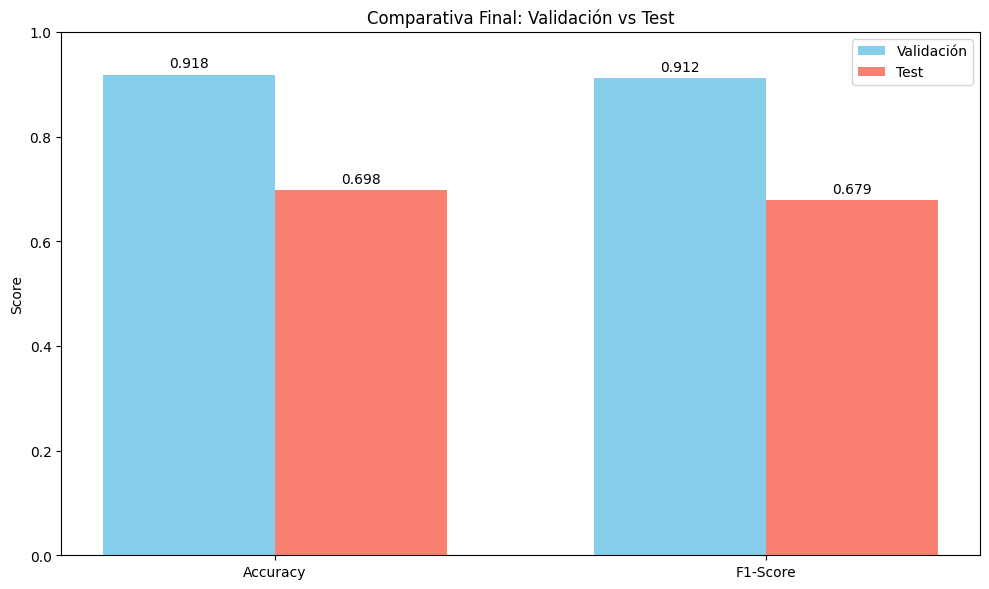

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Intentamos extraer métricas de validación del historial o del último estado
eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]

if not eval_logs:
    print("No se encontraron métricas de validación en el historial. Por favor, asegúrate de haber ejecutado trainer.train() o trainer.evaluate() primero.")
else:
    final_val_metrics = eval_logs[-1]
    test_metrics = test_results.metrics

    # Preparamos los datos para comparar Accuracy y F1
    # Nota: usamos los nombres exactos definidos en tu función compute_metrics
    labels_metrics = ['Accuracy', 'F1-Score']
    val_values = [final_val_metrics.get('eval_accuracy: ', 0), final_val_metrics.get('eval_f1: ', 0)]
    test_values = [test_metrics.get('test_accuracy: ', 0), test_metrics.get('test_f1: ', 0)]

    x = np.arange(len(labels_metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, val_values, width, label='Validación', color='skyblue')
    rects2 = ax.bar(x + width/2, test_values, width, label='Test', color='salmon')

    ax.set_ylabel('Score')
    ax.set_title('Comparativa Final: Validación vs Test')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_metrics)
    ax.set_ylim(0, 1.0)
    ax.legend()

    ax.bar_label(rects1, padding=3, fmt='%.3f')
    ax.bar_label(rects2, padding=3, fmt='%.3f')

    fig.tight_layout()
    plt.show()

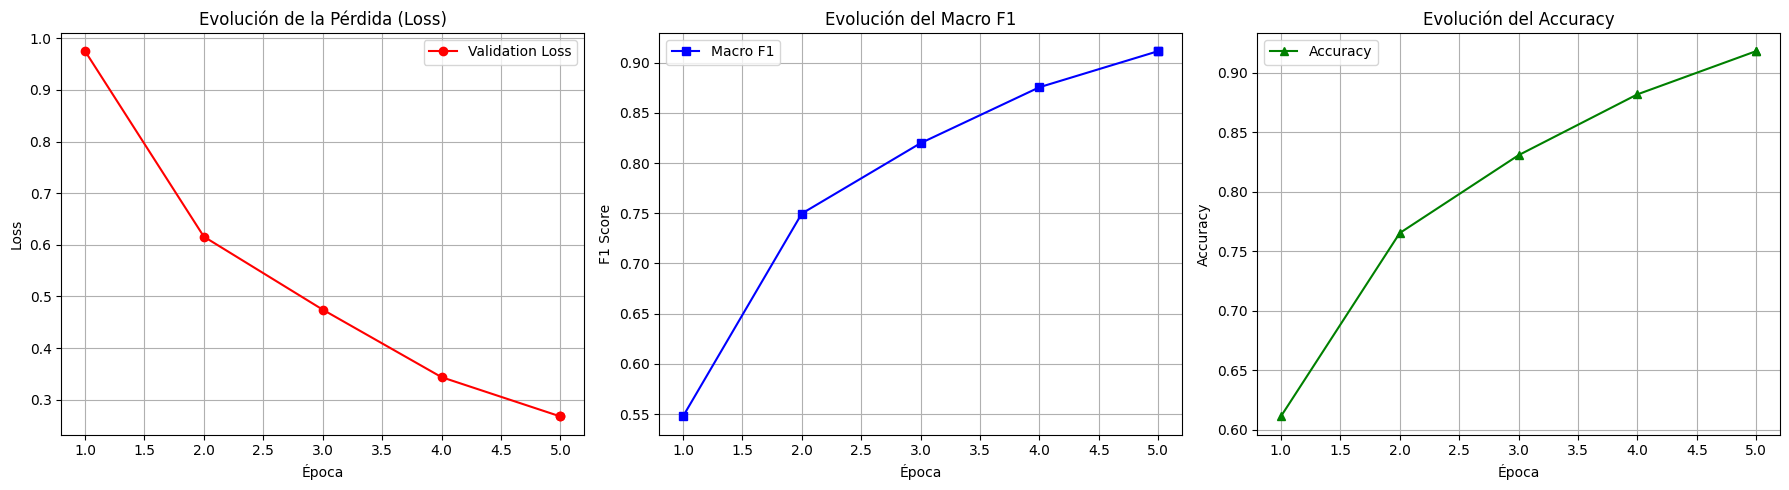

In [ ]:
import matplotlib.pyplot as plt

# Extraemos los logs del trainer
history = trainer.state.log_history

# Filtramos los logs que contienen métricas de evaluación
eval_logs = [log for log in history if 'eval_loss' in log]
epochs = [log['epoch'] for log in eval_logs]
losses = [log['eval_loss'] for log in eval_logs]
f1_scores = [log['eval_f1: '] for log in eval_logs]
accuracy_scores = [log['eval_accuracy: '] for log in eval_logs]

# Crear la figura con tres subplots
plt.figure(figsize=(18, 5))

# Subplot 1: Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, losses, label='Validation Loss', marker='o', color='red')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Subplot 2: F1-Score
plt.subplot(1, 3, 2)
plt.plot(epochs, f1_scores, label='Macro F1', marker='s', color='blue')
plt.title('Evolución del Macro F1')
plt.xlabel('Época')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()

# Subplot 3: Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs, accuracy_scores, label='Accuracy', marker='^', color='green')
plt.title('Evolución del Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()